In [26]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy.optimize import linear_sum_assignment

In [5]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "central_nervous_system_tumor"
pseudobulk = True
ncells = 1000
rd = 1
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [6]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    if pseudobulk:
        fig_name = f"pseudobulk_{dataset}_{tool}_rd{rd}_ncells{ncells}_all_samples_similarity_matrix"
    else:
        fig_name = f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix"

    # Visualize ALL samples against ALL samples
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left", fontdict={"fontsize": 10})
    ax.set_yticklabels(matrix_df.index, fontdict={"fontsize": 10})
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [7]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    if pseudobulk == True:
        fig_name = f"pseudobulk_{dataset}_{tool}_rd{rd}_ncells{ncells}_bulk_vs_singlecell_similarity_matrix"
    else:
        fig_name = f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix"

    # Visualize bulk against single-cell samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [9]:
if pseudobulk:
    vireo_matrix = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/similarity_matrix.csv", index_col=0)
else:
    vireo_matrix = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/real_data/read_depth_{rd}/similarity_matrix.csv", index_col=0)

In [10]:
vireo_matrix.columns = [re.sub(r"[a-zA-Z0-9]{32}_", "", col.replace(".bam", "").replace("ds.", "")) for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([re.sub(r"[a-zA-Z0-9]{32}_", "", idx.replace(".bam", "").replace("ds.", "")) for idx in vireo_matrix.index])

In [11]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [12]:
vireo_matrix.head()

,GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,GSM6467391_pseudobulk_GSM6467391_ncells_1000_3,GSM6467393_pseudobulk_GSM6467393_ncells_1000_1,GSM6467393_pseudobulk_GSM6467393_ncells_1000_2,GSM6467393_pseudobulk_GSM6467393_ncells_1000_3,GSM6467394_pseudobulk_GSM6467394_ncells_1000_1,...,GSM6467423_pseudobulk_GSM6467423_ncells_1000_3,GSM6467424_pseudobulk_GSM6467424_ncells_1000_1,GSM6467424_pseudobulk_GSM6467424_ncells_1000_2,GSM6467424_pseudobulk_GSM6467424_ncells_1000_3,GSM6467425_pseudobulk_GSM6467425_ncells_1000_1,GSM6467425_pseudobulk_GSM6467425_ncells_1000_2,GSM6467425_pseudobulk_GSM6467425_ncells_1000_3,GSM6467426_pseudobulk_GSM6467426_ncells_1000_1,GSM6467426_pseudobulk_GSM6467426_ncells_1000_2,GSM6467426_pseudobulk_GSM6467426_ncells_1000_3
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,0.000000,0.000444,0.000327,0.000583,0.001185,0.000483,0.000514,0.000409,0.000486,0.000525,...,0.000788,0.001492,0.000673,0.001103,0.003581,0.004750,0.001924,0.001040,0.001157,0.001563
GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,0.000444,0.000000,0.000411,0.000662,0.001264,0.000567,0.000593,0.000488,0.000565,0.000609,...,0.000867,0.001579,0.000752,0.001182,0.003660,0.004837,0.002003,0.001119,0.001236,0.001642
GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,0.000327,0.000411,0.000000,0.000528,0.001130,0.000433,0.000459,0.000354,0.000431,0.000461,...,0.000733,0.001431,0.000614,0.001048,0.003526,0.004703,0.001856,0.000977,0.001096,0.001508
GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,0.000583,0.000662,0.000528,0.000000,0.001231,0.000605,0.000653,0.000560,0.000637,0.000685,...,0.000939,0.001630,0.000819,0.001250,0.003730,0.004909,0.002071,0.001190,0.001304,0.001714
GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,0.001185,0.001264,0.001130,0.001231,0.000000,0.001138,0.001244,0.001140,0.001232,0.001287,...,0.001518,0.002226,0.001419,0.001832,0.004329,0.005515,0.002676,0.001786,0.001909,0.002298


In [13]:
vireo_matrix.shape

(90, 90)

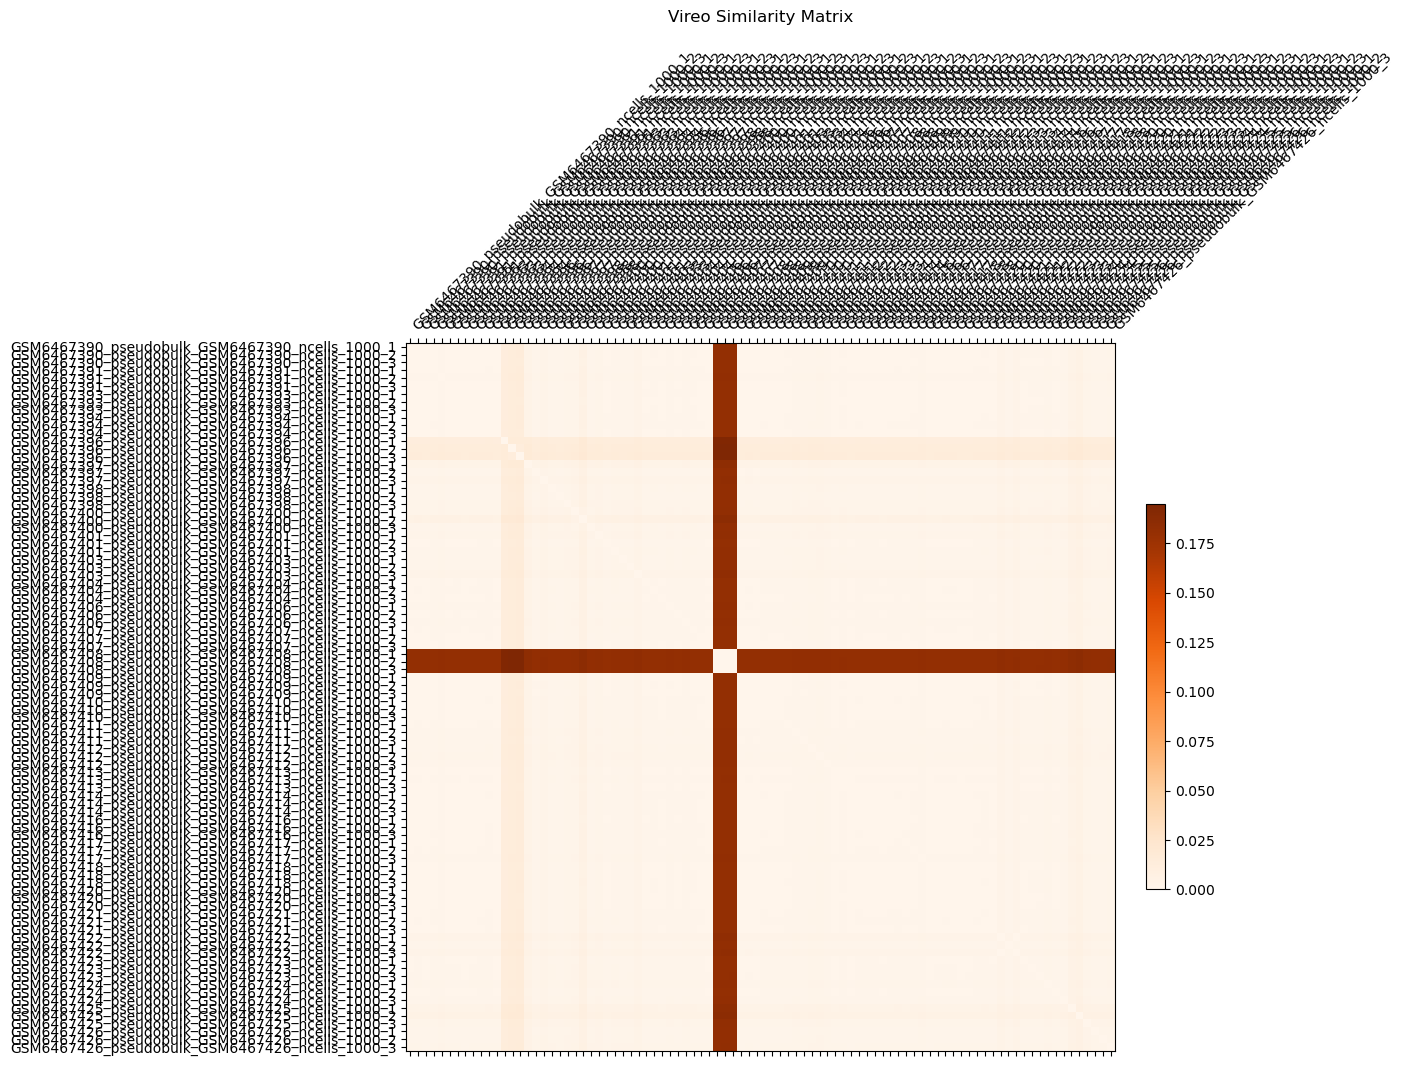

In [14]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [60]:
if pseudobulk:
    vireo_matches = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/matched_samples.csv", index_col=0).reset_index()
else:
    vireo_matches = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/matched_samples.csv", index_col=0).reset_index()

In [61]:
for col in vireo_matches.columns:
    vireo_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace(".bam", "").replace("ds.", "")) for sample in vireo_matches[col]]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [62]:
# How many correct matches?
correct_matches = vireo_matches[vireo_matches["sample_id_0"] == vireo_matches["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches.shape[0]}")

Number of correct matches: 90 out of 90


In [86]:
# Filter Vireo matrix to only samples ending in _1 in rows and samples ending in _2 in columns
vireo_matrix_filtered = vireo_matrix.loc[
    [idx for idx in vireo_matrix.index if idx.endswith("_2")],
    [col for col in vireo_matrix.columns if col.endswith("_3")]
]
# Remove sample with sample_id GSM6467408 in the name
# vireo_matrix_filtered = vireo_matrix_filtered.drop(
#     [idx for idx in vireo_matrix_filtered.index if "GSM6467408" in idx],
#     axis=0
# )
# vireo_matrix_filtered = vireo_matrix_filtered.drop(
#     [col for col in vireo_matrix_filtered.columns if "GSM6467408" in col],
#     axis=1
# )

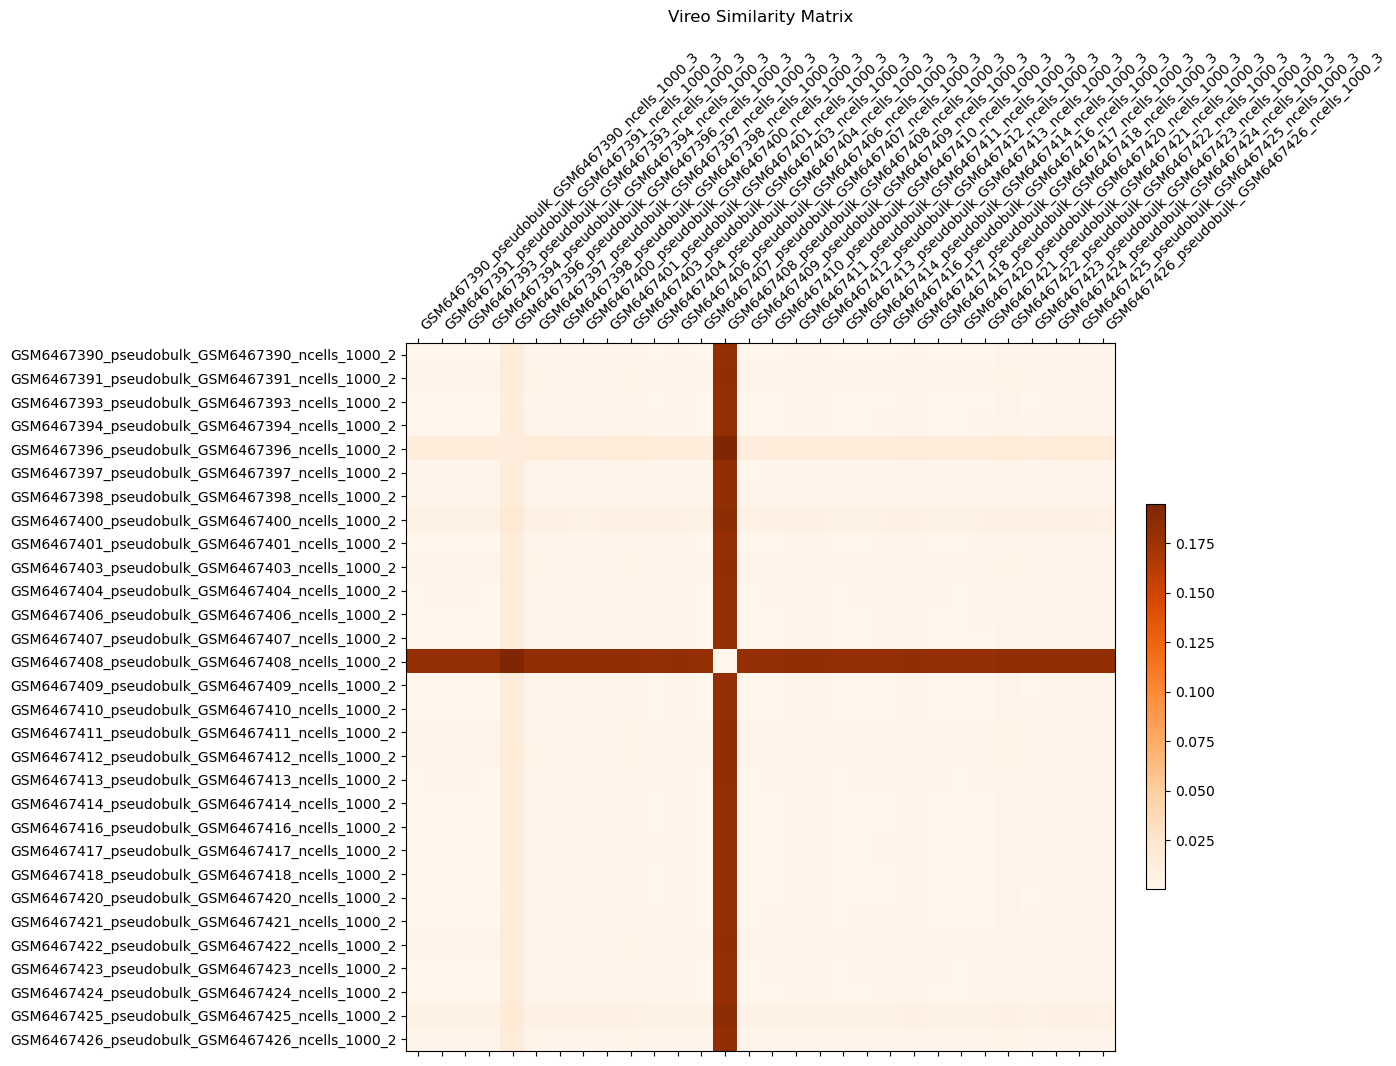

In [87]:
all_samples_matrix_viz(vireo_matrix_filtered, tool="Vireo", dataset=dataset, save_fig=True)

In [88]:
# Minimize diagonal of vireo_matrix_filtered by moving rows and columns around
idx0, idx1 = linear_sum_assignment(vireo_matrix_filtered.values)
vireo_matrix_reordered = pd.DataFrame(vireo_matrix_filtered.iloc[idx0, idx1], index=vireo_matrix_filtered.index[idx0], columns=vireo_matrix_filtered.columns[idx1])

In [89]:
# Check if the rows and columns have the same samples in the same order
vireo_matrix_reordered.index = [re.sub(r"_2$", "", idx) for idx in vireo_matrix_reordered.index]
vireo_matrix_reordered.columns = [re.sub(r"_3$", "", col) for col in vireo_matrix_reordered.columns]

In [90]:
vireo_matches_reordered = pd.DataFrame({
    "sample_id_0": vireo_matrix_reordered.index,
    "sample_id_1": vireo_matrix_reordered.columns
})
# How many correct matches?
correct_matches = vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] == vireo_matches_reordered["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches_reordered.shape[0]}")

Number of correct matches: 30 out of 30


In [91]:
vireo_matrix_reordered.head()

,GSM6467390_pseudobulk_GSM6467390_ncells_1000,GSM6467391_pseudobulk_GSM6467391_ncells_1000,GSM6467393_pseudobulk_GSM6467393_ncells_1000,GSM6467394_pseudobulk_GSM6467394_ncells_1000,GSM6467396_pseudobulk_GSM6467396_ncells_1000,GSM6467397_pseudobulk_GSM6467397_ncells_1000,GSM6467398_pseudobulk_GSM6467398_ncells_1000,GSM6467400_pseudobulk_GSM6467400_ncells_1000,GSM6467401_pseudobulk_GSM6467401_ncells_1000,GSM6467403_pseudobulk_GSM6467403_ncells_1000,...,GSM6467416_pseudobulk_GSM6467416_ncells_1000,GSM6467417_pseudobulk_GSM6467417_ncells_1000,GSM6467418_pseudobulk_GSM6467418_ncells_1000,GSM6467420_pseudobulk_GSM6467420_ncells_1000,GSM6467421_pseudobulk_GSM6467421_ncells_1000,GSM6467422_pseudobulk_GSM6467422_ncells_1000,GSM6467423_pseudobulk_GSM6467423_ncells_1000,GSM6467424_pseudobulk_GSM6467424_ncells_1000,GSM6467425_pseudobulk_GSM6467425_ncells_1000,GSM6467426_pseudobulk_GSM6467426_ncells_1000
GSM6467390_pseudobulk_GSM6467390_ncells_1000,0.000411,0.000567,0.000565,0.000487,0.013785,0.002436,0.001660,0.001339,0.001352,0.002578,...,0.000719,0.001181,0.000583,0.000482,0.000650,0.002434,0.000867,0.001182,0.002003,0.001642
GSM6467391_pseudobulk_GSM6467391_ncells_1000,0.001130,0.001138,0.001232,0.001157,0.014463,0.003086,0.002322,0.002017,0.002019,0.003229,...,0.001413,0.001846,0.001253,0.001163,0.001301,0.003124,0.001518,0.001832,0.002676,0.002298
GSM6467393_pseudobulk_GSM6467393_ncells_1000,0.000354,0.000422,0.000430,0.000382,0.013688,0.002288,0.001548,0.001241,0.001239,0.002444,...,0.000638,0.001061,0.000477,0.000388,0.000511,0.002337,0.000736,0.001045,0.001901,0.001518
GSM6467394_pseudobulk_GSM6467394_ncells_1000,0.000600,0.000726,0.000696,0.000593,0.013944,0.002587,0.001803,0.001474,0.001511,0.002729,...,0.000883,0.001337,0.000735,0.000637,0.000810,0.002586,0.001026,0.001341,0.002151,0.001802
GSM6467396_pseudobulk_GSM6467396_ncells_1000,0.013049,0.013164,0.013162,0.013084,0.012910,0.015033,0.014265,0.013936,0.013949,0.015175,...,0.013332,0.013786,0.013180,0.013083,0.013247,0.015044,0.013464,0.013779,0.014600,0.014239


# NGSCheckmate

In [156]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [157]:
ngscheckmate_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".vcf", "").replace("ds.", "").replace("_individual_variants", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [158]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
GSM7305242_bulk,matched,GSM7305243_bulk,1.0,235.29
GSM7305242_bulk,matched,GSM7305244_bulk,1.0,243.12
GSM7305242_bulk,matched,GSM7305245_bulk,1.0,241.02
GSM7305242_bulk,matched,GSM7305246_bulk,1.0,252.22
GSM7305242_bulk,matched,GSM7305247_bulk,1.0,246.74


In [159]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [160]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [161]:
ngscheckmate_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,2.3529,2.4312,2.4102,2.5222,2.4674,2.5222,2.5222,2.5222,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305243_bulk,2.3529,NaN,2.3529,2.3529,2.3529,2.3529,2.3529,2.3529,2.3529,2.3529,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305244_bulk,2.4312,2.3529,NaN,2.4102,2.4312,2.4312,2.4312,2.4312,2.4312,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305245_bulk,2.4102,2.3529,2.4102,NaN,2.4102,2.4102,2.4102,2.4102,2.4102,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305246_bulk,2.5222,2.3529,2.4312,2.4102,NaN,2.4674,2.5273,2.5273,2.5273,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421


In [131]:
# all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

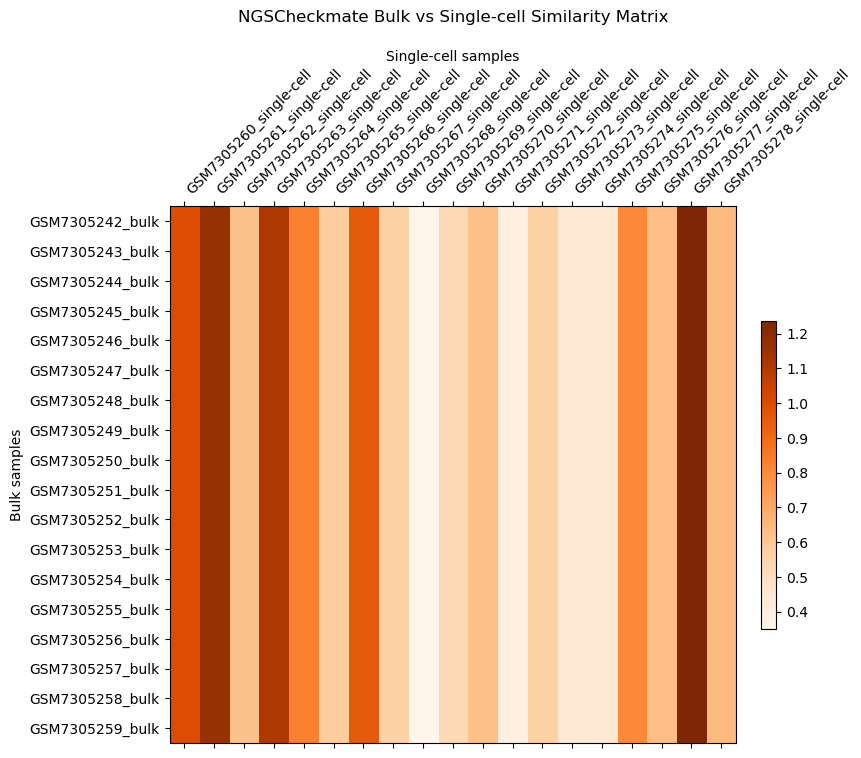

In [162]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

# HYSYS

In [104]:
if pseudobulk:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)
else:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [105]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_individual_variants.snps", "").replace("pseudobulk/", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [106]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,1.000,49
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,0.088,91
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,0.072,83
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,0.000,105
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,0.000,197


In [111]:
def long_df_to_matrix_hysys(df):
    # Use pivot_table for much faster matrix creation
    df_reset = df.reset_index()
    matrix = df_reset.pivot_table(
        index=df_reset.columns[0],  # Use the first column (original index)
        columns='Sample', 
        values='Concordance',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    return matrix

In [112]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [113]:
hysys_matrix.head()

Sample,GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,GSM6467391_pseudobulk_GSM6467391_ncells_1000_3,GSM6467393_pseudobulk_GSM6467393_ncells_1000_1,GSM6467393_pseudobulk_GSM6467393_ncells_1000_2,GSM6467393_pseudobulk_GSM6467393_ncells_1000_3,GSM6467394_pseudobulk_GSM6467394_ncells_1000_1,...,GSM6467423_pseudobulk_GSM6467423_ncells_1000_3,GSM6467424_pseudobulk_GSM6467424_ncells_1000_1,GSM6467424_pseudobulk_GSM6467424_ncells_1000_2,GSM6467424_pseudobulk_GSM6467424_ncells_1000_3,GSM6467425_pseudobulk_GSM6467425_ncells_1000_1,GSM6467425_pseudobulk_GSM6467425_ncells_1000_2,GSM6467425_pseudobulk_GSM6467425_ncells_1000_3,GSM6467426_pseudobulk_GSM6467426_ncells_1000_1,GSM6467426_pseudobulk_GSM6467426_ncells_1000_2,GSM6467426_pseudobulk_GSM6467426_ncells_1000_3
0,,,,,,,,,,,,,,,,,,,,,
GSM6467390_pseudobulk_GSM6467390_ncells_1000_1,1.000,0.088,0.072,0.000,0.000,0.011,0.000,0.000,0.000,0.009,...,0.000,0.004,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000
GSM6467390_pseudobulk_GSM6467390_ncells_1000_2,0.088,1.000,0.059,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.004
GSM6467390_pseudobulk_GSM6467390_ncells_1000_3,0.072,0.059,1.000,0.000,0.000,0.000,0.012,0.000,0.000,0.010,...,0.000,0.004,0.009,0.000,0.000,0.000,0.003,0.006,0.006,0.000
GSM6467391_pseudobulk_GSM6467391_ncells_1000_1,0.000,0.000,0.000,1.000,0.091,0.053,0.020,0.023,0.010,0.000,...,0.007,0.008,0.008,0.005,0.005,0.000,0.003,0.006,0.005,0.004
GSM6467391_pseudobulk_GSM6467391_ncells_1000_2,0.000,0.000,0.000,0.091,1.000,0.067,0.021,0.023,0.005,0.000,...,0.013,0.011,0.005,0.010,0.002,0.000,0.002,0.004,0.004,0.009


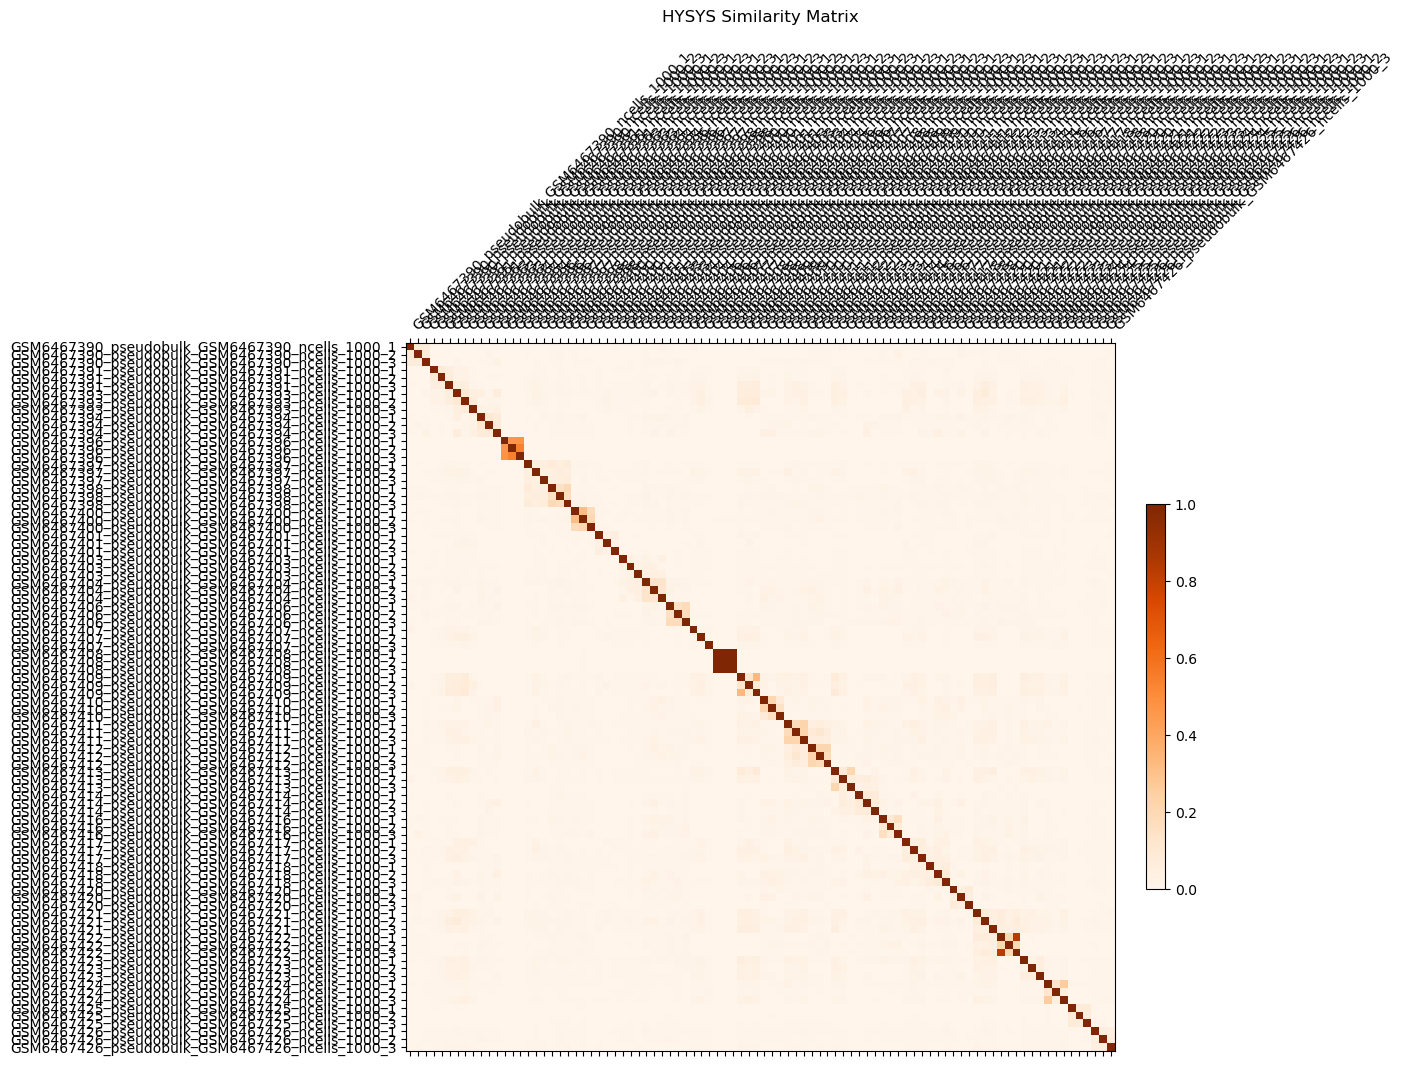

In [114]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [131]:
if pseudobulk:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)
else:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/model_results.txt", sep=",", skiprows=9, header=None)

In [ ]:
print("Shape:", hysys_matches.shape)
print("First few rows:")
hysys_matches.head()

Original columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]
Shape: (90, 90)
First few rows:


,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
0,sample central_nervous_system_tumor/pseudobulk...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...
1,sample central_nervous_system_tumor/pseudobulk...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...
2,sample central_nervous_system_tumor/pseudobulk...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...
3,sample central_nervous_system_tumor/pseudobulk...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6...,'central_nervous_system_tumor/pseudobulk/GSM6.

Just based on the shape of the hysys_matches df and the all the columns being filled  we can conclude that HYSYS claims all samples are related to all other samples...

In [138]:
# Filter HYSYS matrix to only samples ending in _1 in rows and samples ending in _2 in columns
hysys_matrix_filtered = hysys_matrix.loc[
    [idx for idx in hysys_matrix.index if idx.endswith("_1")],
    [col for col in hysys_matrix.columns if col.endswith("_3")]
]

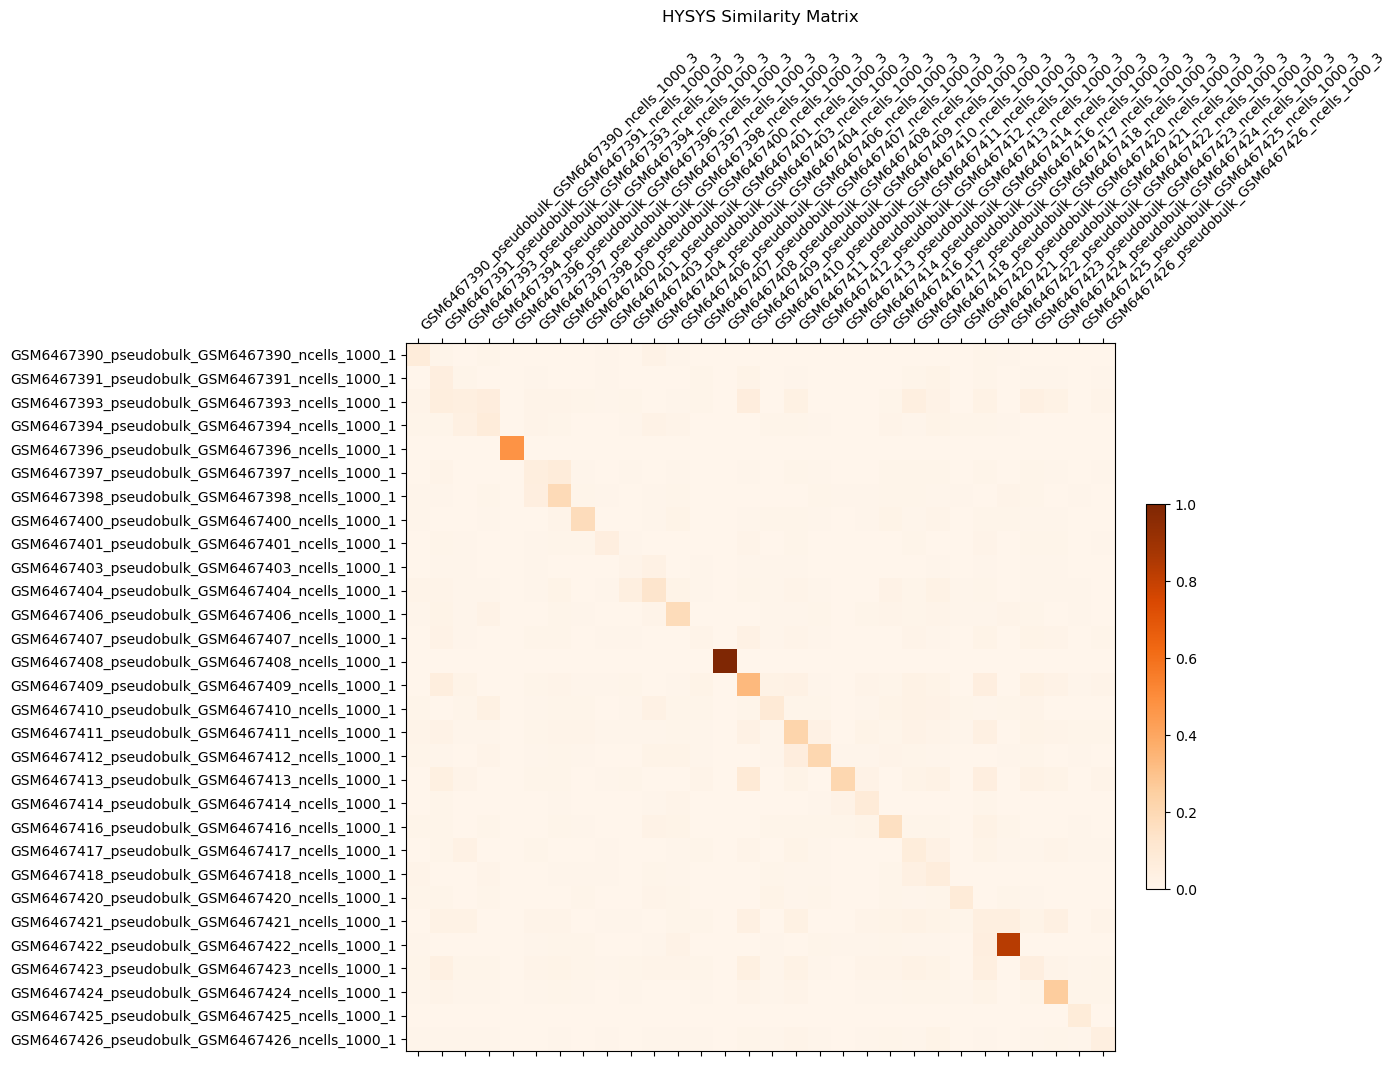

In [139]:
all_samples_matrix_viz(hysys_matrix_filtered, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [170]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [171]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [172]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7305273_single-cell,GSM7305273_single-cell,16.710400,EXPECTED_MATCH
1,GSM7305273_single-cell,GSM7305264_single-cell,-3.771864,EXPECTED_MISMATCH
2,GSM7305273_single-cell,GSM7305250_bulk,-4.595718,EXPECTED_MISMATCH
3,GSM7305273_single-cell,GSM7305266_single-cell,-14.557913,EXPECTED_MISMATCH
4,GSM7305273_single-cell,GSM7305257_bulk,-1.938815,EXPECTED_MISMATCH


In [173]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1])
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [174]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [175]:
fingerprints_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,176.757746,-56.325774,-70.129482,-44.733566,-22.350935,-38.258889,-74.475824,-51.247964,-54.002335,-40.407448,...,-2.920249,-1.909680,-3.689765,-8.143261,-3.729494,-0.868439,-11.470287,-17.640312,-6.911822,-6.026519
GSM7305243_bulk,-56.325774,183.212203,-34.512472,-58.458086,-43.195448,-72.194752,-74.583503,-56.259000,-67.567351,-44.213752,...,-8.767173,-6.343010,-6.905815,-8.771019,-3.415871,-4.479696,-23.977338,-15.219155,-13.069800,-6.856744
GSM7305244_bulk,-70.129482,-34.512472,233.217349,-93.477372,-59.129597,-67.222488,-56.630703,-68.668395,-99.825325,-71.921531,...,-4.827577,-3.371937,-1.873712,-2.403171,-6.055135,-5.564697,-14.627555,-21.705936,-10.215477,-6.010229
GSM7305245_bulk,-44.733566,-58.458086,-93.477372,272.828933,-51.657156,-50.877956,-130.356055,-66.387021,-97.490502,-48.713881,...,-11.548155,0.282157,-5.019313,-0.086428,-4.105136,-0.324088,-18.851721,-13.057030,-9.056541,-13.494638
GSM7305246_bulk,-22.350935,-43.195448,-59.129597,-51.657156,213.092782,-34.299749,-51.141093,-41.007179,-54.470174,-42.313766,...,-4.108299,-6.034705,-3.320115,-3.428074,-4.508520,-1.279984,-28.735335,-39.443069,-13.871475,-15.757328


In [176]:
# all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

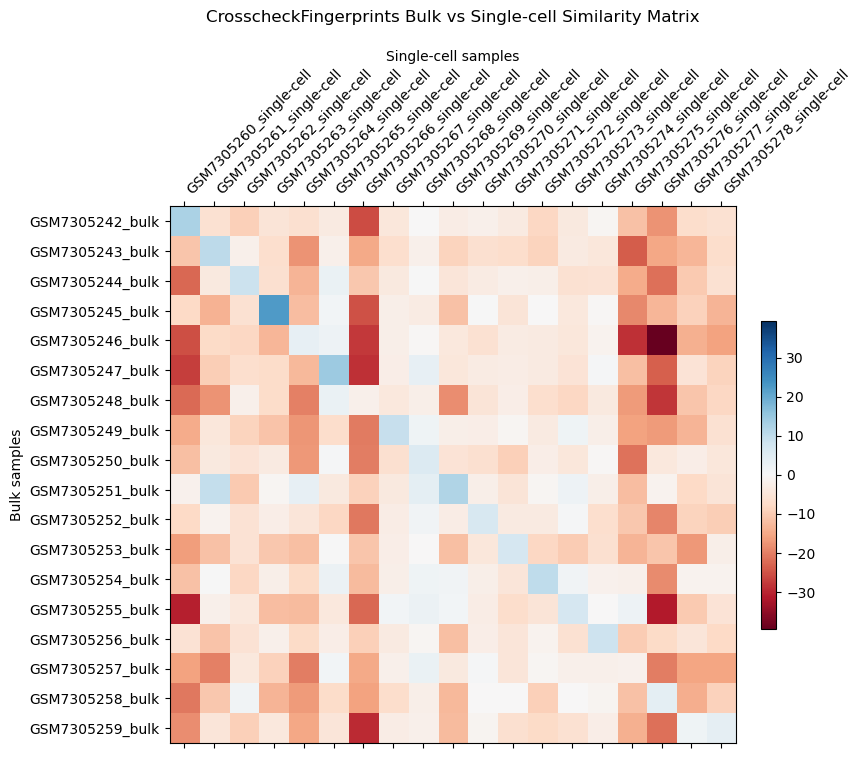

In [177]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [352]:
fingerprints_df["RESULT"].value_counts()

RESULT
EXPECTED_MISMATCH    4360
EXPECTED_MATCH         67
UNEXPECTED_MATCH       62
Name: count, dtype: int64

In [353]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [354]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [355]:
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("polyA") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("polyA"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA,197.938691,UNEXPECTED_MATCH
1,HGSOC-2023_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA,186.372326,UNEXPECTED_MATCH
2,HGSOC-2094_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA,204.709169,UNEXPECTED_MATCH
3,HGSOC-2126_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA,221.965748,UNEXPECTED_MATCH
4,HGSOC-2129_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA,182.191976,UNEXPECTED_MATCH
5,HGSOC-2186_bulk_chunk_ribo,HGSOC-2186_bulk_diss_polyA,205.165566,UNEXPECTED_MATCH
6,HGSOC-2202_bulk_chunk_ribo,HGSOC-2202_bulk_diss_polyA,227.722145,UNEXPECTED_MATCH
7,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_diss_polyA,195.143683,UNEXPECTED_MATCH
8,HGSOC-2209_bulk_diss_polyA,HGSOC-2526_bulk_chunk_ribo,193.867424,UNEXPECTED_MATCH
9,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_diss_polyA,244.463959,UNEXPECTED_MATCH


# BAMixChecker

In [66]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [67]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [68]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
GSM7305243_bulk,GSM7305270_single-cell,0.0,Unmatched
GSM7305243_bulk,GSM7305249_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305248_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305253_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305252_bulk,0.0,Unmatched


In [69]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [70]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [71]:
bamixchecker_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305243_bulk,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305244_bulk,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305245_bulk,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305246_bulk,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
# all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

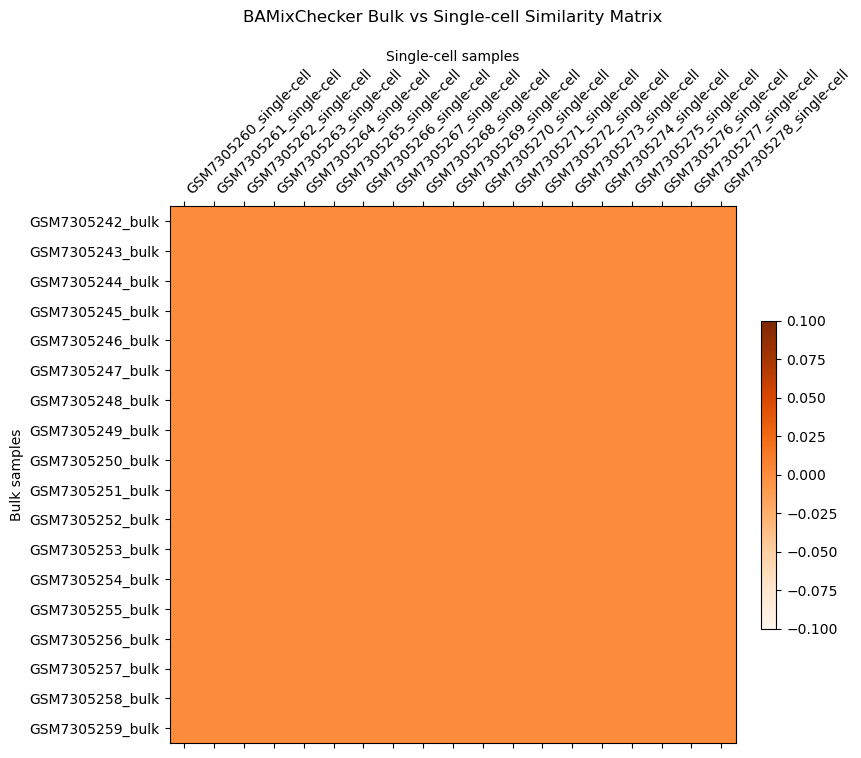

In [73]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

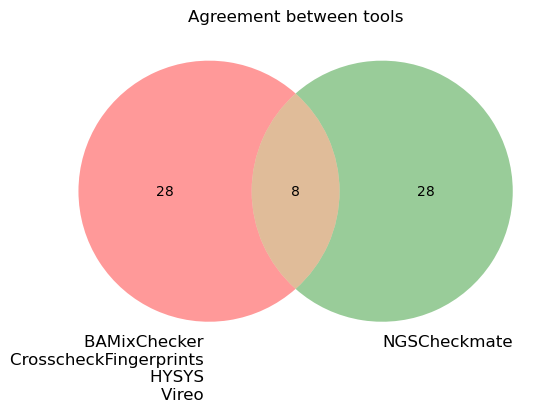

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300